In [ ]:
# %reload_ext autoreload
# %autoreload 2

from tqdm import trange
from flygym.compose import ActuatorType
from miniproject.simulation import MiniprojectSimulation
from submission.controller import Controller
import matplotlib.pyplot as plt
import numpy as np
#Seed 1 ok :)
#Seed 67 

#Prmts:
#Width threshold for obstacle detection 
#Vision threshold to only keep center vision 
#seed 1 works well

#seed 777 ok tune a reduuce a bit threshold for stuck 
#seed 1 ok 

# exam seed 1, 67, 777
sim = MiniprojectSimulation(level=2, seed=777)
controller = Controller(sim)
banana_xy= np.array(sim.world.banana_xy)
min_dist=np.inf
step_min=0
for step in trange(75000):

    head_pos = controller.get_head_position(sim)
    fly_xy = np.array([head_pos[0],head_pos[1]]) 
    dist = np.linalg.norm(fly_xy - banana_xy)
    
    if dist <= min_dist: 
        step_min=step
        min_dist = dist 
    
    joint_angles, adhesion = controller.step(sim)
    sim.set_actuator_inputs(sim.fly.name, ActuatorType.POSITION, joint_angles)
    sim.set_actuator_inputs(sim.fly.name, ActuatorType.ADHESION, adhesion)
    sim.step()
    sim.render_as_needed()
    
print(f"min dist", min_dist,"min step",step_min)   
controller.close()
sim.renderer.show_in_notebook()

  0%|          | 0/75000 [00:00<?, ?it/s]

final dist 2.753516425691601


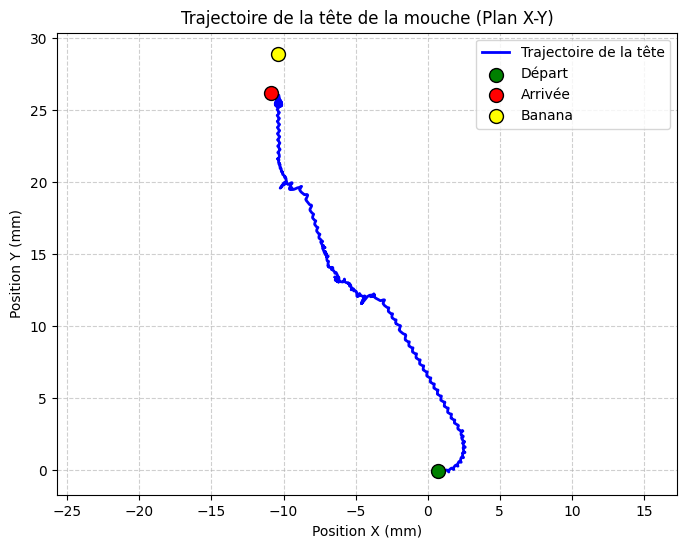

In [2]:
controller.plot_head_trajectory(sim)


In [2]:
print(sim.world.banana_xy)

(np.float64(-16.675396636978267), np.float64(-23.91126942978231))


In [1]:
import numpy as np
import tqdm
from flygym.compose import ActuatorType
from miniproject import MiniprojectSimulation
from submission.controller import Controller

MAX_NUM_STEPS = 70000
NUM_SEEDS = 5
LEVEL = 2  # change as needed
SUCCESS_RADIUS = 3.0

def run_single_seed(seed):
    sim = MiniprojectSimulation(level=LEVEL, seed=seed, back_cam=False, top_cam=False)
    controller = Controller(sim)

    def get_distance():
        fly_xy = np.array(sim.get_body_positions(sim.fly.name)[0][:2])
        banana_xy = np.array(sim.world.banana_xy)
        #print("banana",banana_xy)
        return np.linalg.norm(fly_xy - banana_xy)

    for step in range(MAX_NUM_STEPS):
        dist = get_distance()
        if dist <= SUCCESS_RADIUS:
            print(f"  seed={seed} → reached banana in {step} steps (dist={dist:.2f})")
            return dist

        joint_angles, adhesion_signals = controller.step(sim)
        sim.set_actuator_inputs(sim.fly.name, ActuatorType.POSITION, joint_angles)
        sim.set_actuator_inputs(sim.fly.name, ActuatorType.ADHESION, adhesion_signals)
        sim.step()

    final_dist = get_distance()
    print(f"  seed={seed} → timed out (final dist={final_dist:.2f})")
    return final_dist


distances = []
seeds = np.random.randint(0, 800, size=NUM_SEEDS)

#seeds=[1]
for seed in tqdm.tqdm(seeds):
    d = run_single_seed(int(seed))
    distances.append(d)
# d=run_single_seed(1)
# distances.append(d)

distances = np.array(distances)
print(f"\n--- Results over {NUM_SEEDS} seeds ---")
print(f"  Mean final distance : {distances.mean():.2f}")
print(f"  Std                 : {distances.std():.2f}")
print(f"  Min / Max           : {distances.min():.2f} / {distances.max():.2f}")
print(f"  Success rate (≤{SUCCESS_RADIUS}mm): {(distances <= SUCCESS_RADIUS).mean()*100:.0f}%")

 20%|██        | 1/5 [02:05<08:22, 125.58s/it]

  seed=735 → timed out (final dist=19.21)


OpenCV: FFMPEG: tag 0x39305056/'VP09' is not supported with codec id 167 and format 'webm / WebM'


Fin Stuck Mode au step 11430. Et c'est reparti pour un touuuur
Fin Stuck Mode au step 46294. Et c'est reparti pour un touuuur
Fin Stuck Mode au step 55293. Et c'est reparti pour un touuuur
Fin Stuck Mode au step 64292. Et c'est reparti pour un touuuur


 40%|████      | 2/5 [04:20<06:34, 131.36s/it]

...

Fin Stuck Mode au step 50993. Et c'est reparti pour un touuuur


 80%|████████  | 4/5 [08:42<02:09, 129.94s/it]

  seed=123 → timed out (final dist=11.01)


OpenCV: FFMPEG: tag 0x39305056/'VP09' is not supported with codec id 167 and format 'webm / WebM'
100%|██████████| 5/5 [10:19<00:00, 123.92s/it]

  seed=476 → reached banana in 57506 steps (dist=3.00)

--- Results over 5 seeds ---
  Mean final distance : 13.21
  Std                 : 6.02
  Min / Max           : 3.00 / 19.23
  Success rate (≤3.0mm): 20%


In [2]:
controller.plot_head_trajectory(sim)


NameError: name 'controller' is not defined